# HMM states caller module for the PySMACKS framework
## Update 2026-04-10
*by Bastien Molcrette*

*License: MIT*

In this notebook, we perform the following tasks:
* trace-by-trace HMM inference
* extraction of the individual transition matrices (one per trace)
* Ensemble HMM on the entire traces dataset, with common initial probabilities vector and transition matrix, but individual mean and covariance matrices for each traces

## Python modules

Import the python files utils.py and GUI_HMM_utils.py from the PySMACKS framework

In [1]:
from utils import *
from GUI_HMM_utils import *

*Optional: if you want to interact with the figures, load the following module*

In [2]:
import IPython
%matplotlib widget

## Input parameters

Indicate the framerate corresponding to this dataset, ie. the number of frames per seconds (or 1 / blocktime , in seconds)

In [3]:
framerate = 10

Indicate the number of hidden states you postulate

In [4]:
nb_hidden_states = 2

## Import of the traces dataset

Select the background corrected trace dataset (JSON file)

In [5]:
traces_dict_DA_QC = load_JSON_traces_data()

Traces dataset loaded!


## Trace-by-trace HMM inference

Run the trace-by-trace (TbT) HMM inference on each individual traces. The output of this step generates an updated dictionnary with all traces data, metadata and TbT HMM results as additional key.

In details, a new key 'HMM_param' is added to each individual traces, with the following internal structure:
- 'covar_mat': covariance matrix for the gaussian emission probabilities
- 'means': mean vector for the gaussian emission probabilities
- 'predict': list of predicted states for the trace over time; state 0 = lower FRET --> state nb_hidden_states = higher FRET
- 'start_prob': starting probabilities vector
- 'trans_mat': transition matrix

In [6]:
traces_dict_DA_QC, stack_rate_mat, stack_prob_init = TbT_HMM_pipeline(traces_dict_DA_QC, 
                                                                      nb_hidden_states = nb_hidden_states)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


Plot the extracted TbT kinetic rates distribution as boxplots

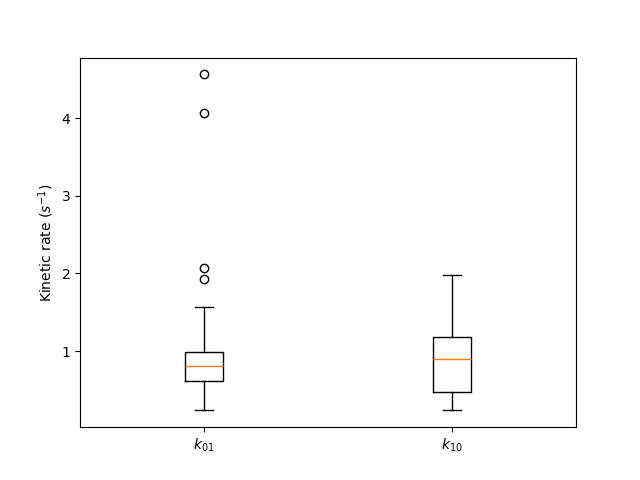

In [7]:
plot_TbT_kin_rates(stack_rate_mat, framerate = framerate)

Additionally, you can visualize the states inference results for each individual trace using the following cell; you can change the specific trace you are looking at by changing the variable plot_ID (integer value between 0 and number of traces - 1)

*The 'scale' parameter in the plot function can be tuned to scale the display of the HMM state values (black curve) to the other data, so it's easier to view them together.*

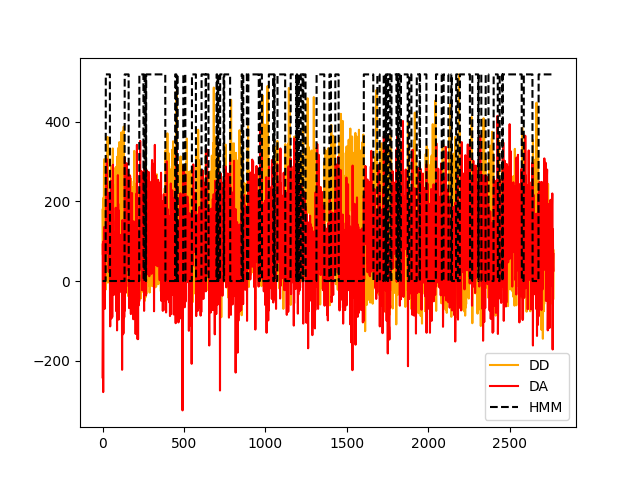

In [8]:
plot_ID = 0 # CHANGE THIS TO VIEW ANOTHER TRACE

plot_trace_with_HMM(traces_dict_DA_QC, ID = plot_ID, scale = 1)

## Ensemble HMM on all traces

In this last section, run the Ensemble HMM on all traces. The initial guess for the transition matrix and the starting probabilities are taken as the mean values over all individual matrices from the TbT inferences. The mean and covariance for the emission probabilities are taken from the values stored into the traces dictionnary.

The output of this section are the ensemble transition matrix and ensemble starting probabilities vector.

In [9]:
# Generate first initial guess for the rate matrix and and starting probabilities, by taking the mean values from the TbT results

trans_mat_0 = np.mean(stack_rate_mat, axis = 0)
prob_init_0 = np.mean(stack_prob_init, axis = 0)

# Run the Ensemble HMM on all traces

Ens_trans_mat, Ens_start_prob = Ens_HMM(traces_dict_DA_QC, trans_mat_0, prob_init_0)

Extract the ensemble kinetic rates from the ensemble transformation matrix

In [10]:
print('Rates estimated from the Ensemble HMM:')
for i in range(nb_hidden_states):
        for j in range(nb_hidden_states):
            if i != j:
                label_i = 'k_{' + str(i) + str(j) + '} = ' + str(np.round(Ens_trans_mat[i,j]*framerate, 4)) + ' s^{-1}'
                print(label_i)

Rates estimated from the Ensemble HMM:
k_{01} = 0.8223 s^{-1}
k_{10} = 0.8088 s^{-1}


## Save the results

Save the updated traces dictionnary as a JSON file.

In [11]:
save_traces_dict(traces_dict_DA_QC)

Traces dataset saved as JSON file to path: E:/Bastien/M1/traces_dataset_M1_20260410_DA_QC_HMM.json
